In [1]:
import os

dataset_path = "dataset"

classes = os.listdir(dataset_path)

for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(f"{cls}: {len(os.listdir(path))} images")

Bacterial leaf blight: 40 images
Brown spot: 40 images
Leaf smut: 39 images


Image Visualization

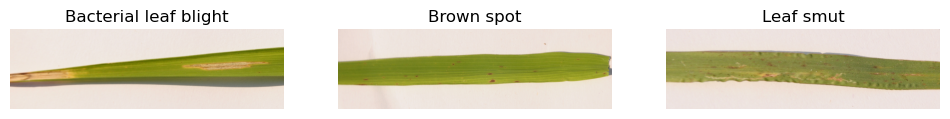

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

dataset_path = "dataset"

classes = os.listdir(dataset_path)

plt.figure(figsize=(12,4))

for i, cls in enumerate(classes):
    
    img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    
    img_path = os.path.join(dataset_path, cls, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

### Image Preprocessing + Augmentation

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


### Deep Learning Model Build Karo

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load Pretrained Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

# Build Final Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Train The Model

In [5]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5000 - loss: 1.1897 - val_accuracy: 0.7826 - val_loss: 0.8226
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6250 - loss: 0.8687 - val_accuracy: 0.9130 - val_loss: 0.4742
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7604 - loss: 0.5364 - val_accuracy: 0.8261 - val_loss: 0.5700
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8438 - loss: 0.4004 - val_accuracy: 0.9130 - val_loss: 0.4210
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9062 - loss: 0.2728 - val_accuracy: 0.9130 - val_loss: 0.4169
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9271 - loss: 0.2188 - val_accuracy: 0.9130 - val_loss: 0.3600
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9271 - loss: 0.2185 - val_accuracy: 0.9130 - val_loss: 0.3932
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9479 - loss: 0.1900 - val_accuracy: 0.9130 - val_loss: 0.3666
Epoch 9/10
6/6 

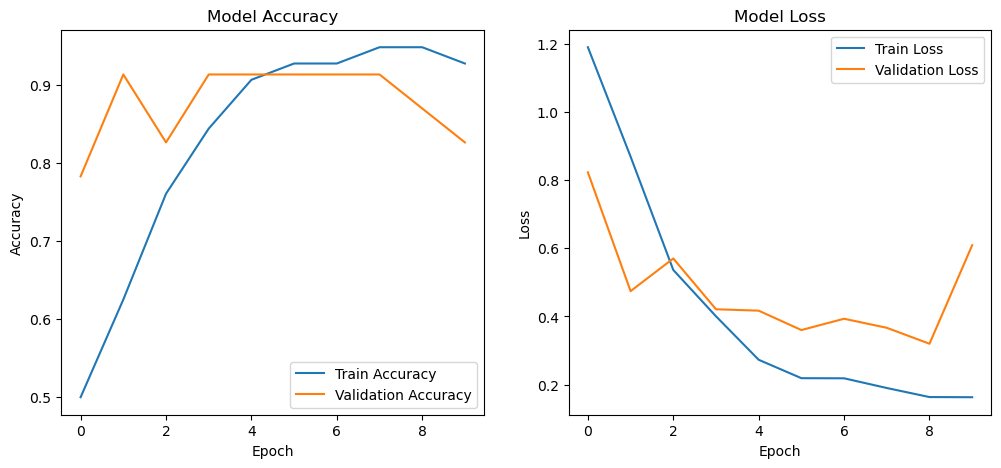

In [6]:
# Accuracy Graphs
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [7]:
# save model
model.save("saved_models/rice_leaf_disease_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [8]:
# Prediction Test System

import numpy as np
from tensorflow.keras.preprocessing import image

class_names = list(train_generator.class_indices.keys())

def predict_image(img_path):
    
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

In [10]:
# testing
predict_image("D:\Rice_Leaf_Disease_Project-datamites\dataset\Brown spot\DSC_0394.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Prediction: Brown spot
Confidence: 91.16%


### Confusion Matrix + Classification Report

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
Y_pred = model.predict(val_generator)

y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = val_generator.classes

# Class names
class_names = list(val_generator.class_indices.keys())

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
                       precision    recall  f1-score   support

Bacterial leaf blight       0.38      0.38      0.38         8
           Brown spot       0.60      0.38      0.46         8
            Leaf smut       0.30      0.43      0.35         7

             accuracy                           0.39        23
            macro avg       0.42      0.39      0.40        23
         weighted avg       0.43      0.39      0.40        23

[[3 1 4]
 [2 3 3]
 [3 1 3]]


### Confusion Matrix Visualization

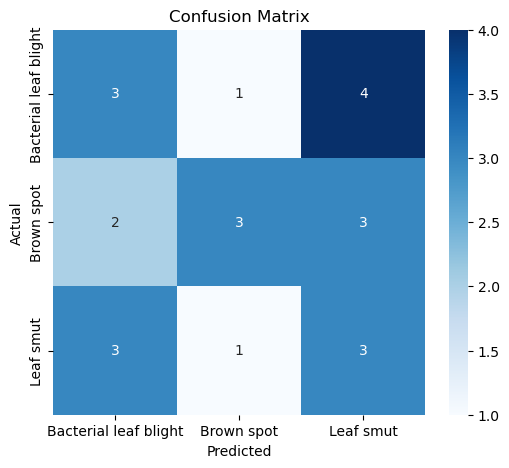

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()